# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE CANCIONES SEGÚN GENEROS MUSICALES**

El objetivo de este trabajo es construir una red neuronal recurrente (RNN) utilizando Pytorch, capaz de clasificar géneros musicales a partir del fragmento de una canción en formato .wav. El clasificador deberá identificar uno de los 10 géneros : blues, classical, country, disco, hiphop, jazz, metal, pop, reggae o rock. El dataset se encuentra en este link: https://drive.google.com/file/d/1txyVxGVezQ4fcHqFi-n3gcWKEYQexu1_/view?usp=sharing

# 1. Preprocesamiento de los datos (2 puntos)

Antes de entrenar el modelo de clasificación, es necesario transformar los archivos de audio en una representación numérica que pueda ser procesada por una red neuronal recurrente (RNN). En este trabajo se utilizarán **MFCCs (Mel-Frequency Cepstral Coefficients)**, una de las representaciones más empleadas en tareas de análisis de audio, reconocimiento de voz y clasificación musical.

El flujo general de preprocesamiento es el siguiente:

```text
Archivo WAV
    ↓
Carga del audio
    ↓
Conversión a una frecuencia de muestreo común
    ↓
Extracción de MFCCs
    ↓
Ajuste de longitud temporal
    ↓
Normalización
    ↓
Conversión a tensor
```

## A. Carga del audio

Cada archivo de audio es cargado utilizando la función **`librosa.load()`** de la biblioteca **Librosa**. Durante este proceso se establece una frecuencia de muestreo uniforme para todos los archivos.

La frecuencia de muestreo utilizada puede ser:

$$
f_s = 22050 Hz
$$

Esto significa que cada segundo de audio se representa mediante 22 050 muestras. **Pero pueden elegir otra fs si lo consideran mejor.**

Además, se considera una duración máxima de 30 segundos por canción, correspondiente a la duración estándar de los audios del dataset GTZAN.

## B. Extracción de características mediante MFCC

Una vez cargado el audio, se calculan los **Mel-Frequency Cepstral Coefficients (MFCC)** mediante la función **`librosa.feature.mfcc()`**.

Los MFCC permiten representar el contenido espectral del audio de una manera compacta, capturando características relevantes para distinguir entre distintos géneros musicales.

Un valor balanceado podría ser:

$$
n_{MFCC} = 40
$$

coeficientes por cada instante temporal. **Pero pueden cambiarlo si desean.**

Conceptualmente, los MFCC se obtienen mediante las siguientes etapas:

1. Transformada rápida de Fourier (FFT).
2. Aplicación de filtros en escala Mel.
3. Obtención de la energía logarítmica de cada banda.
4. Transformada discreta del coseno (DCT).

La conversión entre frecuencia real y frecuencia Mel se define como:

$$
Mel(f)=2595\log_{10}\left(1+\frac{f}{700}\right)
$$

Esta escala aproxima la forma en que el oído humano percibe las diferencias de frecuencia.

Tras la extracción de características, cada canción queda representada por una matriz de dimensiones:

**(40, T)**

donde:

* **40** representa la cantidad de coeficientes MFCC calculados para cada frame.
* **T** representa el número de frames temporales.

Pero recomiendo hallar la transpuesta `.T` para obtener **(T, 40)**.

## C. Ajuste de longitud temporal

Las RNNs requieren que todas las muestras de un mismo lote tengan dimensiones consistentes.

Sin embargo, debido a pequeñas diferencias en la duración efectiva de los audios y en el proceso de extracción de características, la cantidad de frames temporales puede variar ligeramente entre canciones.

Para solucionar este problema se define una longitud máxima, la cual puede ser:

$$
T_{max}=1300
$$

Si una secuencia contiene menos de 1300 frames, se agregan valores nulos al final de la secuencia (*padding*).

Si una secuencia contiene más de 1300 frames, se eliminan los frames excedentes (*truncation*).

De esta forma, todas las canciones quedan representadas mediante matrices de tamaño:

**(1300, 40)**

lo que facilita la construcción de lotes de entrenamiento.

**Pero no es obligatorio que usen 1300, prueben con otro valor a ver si mejora.**

## D. Normalización de características

Antes de alimentar los datos al modelo, los MFCC se normalizan para reducir diferencias de escala entre muestras.

La normalización utilizada corresponde a una estandarización tipo Z-score:

$$
x_{norm}=\frac{x-\mu}{\sigma}
$$

donde:

* $x$ es el valor original.
* $\mu$ es la media de la muestra.
* $\sigma$ es la desviación estándar.

Tras este proceso, los datos presentan aproximadamente:

* Media cercana a cero.
* Desviación estándar cercana a uno.

La normalización mejora la estabilidad numérica y acelera la convergencia durante el entrenamiento.

## E. Conversión a tensores

Finalmente, las matrices obtenidas se convierten a tensores de **PyTorch** mediante la función **`torch.tensor()`**.

Cada muestra queda representada por una secuencia temporal con dimensiones:

**(1300, 40)**

donde:

* 1300 corresponde al número de pasos temporales.
* 40 corresponde al número de coeficientes MFCC por cada paso temporal.

Durante el entrenamiento, las muestras se agrupan en lotes (*batches*), por lo que la entrada al modelo tendrá la forma:

**(BatchSize, 1300, 40)**

donde:

* **BatchSize** representa la cantidad de canciones procesadas simultáneamente.
* **1300** representa la longitud temporal de la secuencia.
* **40** representa el número de características extraídas por instante temporal.

Estas secuencias constituyen la entrada del modelo recurrente encargado de clasificar la canción en uno de los diez géneros musicales presentes en el dataset GTZAN.


In [8]:
from pathlib import Path
import numpy as np
import librosa
import torch
import random
import copy
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [5]:
seed = 7 # Semilla para reproducibilidad
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [2]:
DATASET_PATH = "datos_music/genres_original"

SR = 22050
N_MFCC = 40
MAX_LEN = 1300

data_dir = Path(DATASET_PATH)
genres = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
label_to_idx = {genre: i for i, genre in enumerate(genres)}
idx_to_label = {i: genre for genre, i in label_to_idx.items()}

def extraer_mfcc(ruta_audio, sr=SR, n_mfcc=N_MFCC, max_len=MAX_LEN):
  y, _ = librosa.load(ruta_audio, sr=sr, mono=True)
  mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T  # (T, 40)

  if mfcc.shape[0] < max_len:
    mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)), mode="constant")
  else:
    mfcc = mfcc[:max_len, :]

  mean = mfcc.mean(axis=0, keepdims=True)
  std = mfcc.std(axis=0, keepdims=True)
  std[std == 0] = 1.0
  mfcc = (mfcc - mean) / std

  return mfcc.astype(np.float32)

X, y, archivos = [], [], []

for ruta in sorted(data_dir.glob("*/*.wav")):
  try:
    X.append(extraer_mfcc(ruta))
    y.append(label_to_idx[ruta.parent.name])
    archivos.append(str(ruta))
  except Exception as e:
    print(f"Error procesando {ruta}: {e}")

X = np.stack(X)  # (N, 1300, 40)
y = np.array(y, dtype=np.int64)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
dataset_tensor = torch.utils.data.TensorDataset(X_tensor, y_tensor)

print("Géneros:", genres)
print("Cantidad de archivos procesados:", len(archivos))
print("Shape X:", X_tensor.shape)
print("Shape y:", y_tensor.shape)

Géneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Cantidad de archivos procesados: 999
Shape X: torch.Size([999, 1300, 40])
Shape y: torch.Size([999])


## 2. Construcción y entrenamiento del modelo recurrente (4 puntos)

* Construir dos modelos de clasificación de géneros musicales utilizando PyTorch. Uno basado en una RNN clásica y el otro en una LSTM.
* No se deben utilizar modelos pre-entrenados. La arquitectura debe ser implementada y entrenada desde cero.
* Analizar correctamente qué funciones de activación son adecuadas, qué tamaño de estado oculto se empleará, cuántas capas recurrentes tendrán los modelos, si se usará dropout, qué learning rate se aplicará, qué función de costo se utilizará y qué optimizador se empleará.


In [41]:
BATCH_SIZE = 32

train_idx = []
val_idx = []
num_classes = len(genres)

for class_idx in range(num_classes):
  class_samples = np.where(y == class_idx)[0]
  n_samples = len(class_samples)
  n_val = max(1, int(0.2 * n_samples))

  np.random.seed(seed)
  np.random.shuffle(class_samples)
  
  val_idx.extend(class_samples[:n_val])
  train_idx.extend(class_samples[n_val:])

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)

X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_val, y_val = X_tensor[val_idx], y_tensor[val_idx]

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

y_train_np = y_train.cpu().numpy()
y_val_np = y_val.cpu().numpy()

print("\nDistribución por clase:")
for i, genre in enumerate(genres):
  train_count = np.sum(y_train_np == i)
  val_count = np.sum(y_val_np == i)
  print(f"{genre}: Train={train_count}, Val={val_count}")

Train: 800 | Val: 199

Distribución por clase:
blues: Train=80, Val=20
classical: Train=80, Val=20
country: Train=80, Val=20
disco: Train=80, Val=20
hiphop: Train=80, Val=20
jazz: Train=80, Val=19
metal: Train=80, Val=20
pop: Train=80, Val=20
reggae: Train=80, Val=20
rock: Train=80, Val=20


In [42]:
def evaluate_model(model, data_loader, loss_fn, device):
  model.eval()
  running_loss = 0.0
  all_preds = []
  all_targets = []

  with torch.no_grad():
    for xb, yb in data_loader:
      xb, yb = xb.to(device), yb.to(device)
      logits = model(xb)
      loss = loss_fn(logits, yb)
      running_loss += loss.item() * xb.size(0)

      preds = torch.argmax(logits, dim=1)
      all_preds.extend(preds.cpu().numpy())
      all_targets.extend(yb.cpu().numpy())

  avg_loss = running_loss / len(data_loader.dataset)
  acc = accuracy_score(all_targets, all_preds)
  f1 = f1_score(all_targets, all_preds, average="macro")
  return avg_loss, acc, f1

def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, device):
  history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
  }

  for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for xb, yb in train_loader:
      xb, yb = xb.to(device), yb.to(device)

      optimizer.zero_grad()
      logits = model(xb)
      loss = loss_fn(logits, yb)
      loss.backward()
      optimizer.step()

      running_loss += loss.item() * xb.size(0)
      preds = torch.argmax(logits, dim=1)
      all_preds.extend(preds.detach().cpu().numpy())
      all_targets.extend(yb.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(all_targets, all_preds)
    train_f1 = f1_score(all_targets, all_preds, average="macro")

    val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
      f"Epoch [{epoch}/{epochs}] | "
      f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

  return model, history

Dropout bastante elevado porque en la practiva el accuracy de train era mucho mayor al de test con unos mas chicos

In [48]:
EPOCHS = 10
LR = 1e-3
INPUT_SIZE = N_MFCC

HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.4

torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class RNNModel(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.rnn = nn.RNN(
      input_size=INPUT_SIZE,
      hidden_size=HIDDEN_SIZE,
      num_layers=NUM_LAYERS,
      nonlinearity="tanh",
      batch_first=True,
      dropout=DROPOUT
    )
    self.fc = nn.Linear(HIDDEN_SIZE, num_classes)

  def forward(self, x):
    out, _ = self.rnn(x)
    last_timestep = out[:, -1, :]
    return self.fc(last_timestep)

loss_fn = nn.CrossEntropyLoss()
rnn_model = RNNModel(num_classes=num_classes).to(device)
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=LR, weight_decay=1e-4)
rnn_model, rnn_history = train_model(
  rnn_model, train_loader, val_loader, loss_fn, rnn_optimizer, EPOCHS, device
)

Device: cuda
Epoch [1/10] | Train Loss: 2.0424, Train Acc: 0.2550, Train F1: 0.1855 | Val Loss: 1.7407, Val Acc: 0.3518, Val F1: 0.2600
Epoch [2/10] | Train Loss: 1.6435, Train Acc: 0.4263, Train F1: 0.3761 | Val Loss: 1.5216, Val Acc: 0.4322, Val F1: 0.4073
Epoch [3/10] | Train Loss: 1.4590, Train Acc: 0.4850, Train F1: 0.4582 | Val Loss: 1.4418, Val Acc: 0.4171, Val F1: 0.3765
Epoch [4/10] | Train Loss: 1.3424, Train Acc: 0.5250, Train F1: 0.5065 | Val Loss: 1.3758, Val Acc: 0.4925, Val F1: 0.4559
Epoch [5/10] | Train Loss: 1.2517, Train Acc: 0.5525, Train F1: 0.5399 | Val Loss: 1.3520, Val Acc: 0.5025, Val F1: 0.4814
Epoch [6/10] | Train Loss: 1.1994, Train Acc: 0.5850, Train F1: 0.5746 | Val Loss: 1.3553, Val Acc: 0.5226, Val F1: 0.4757
Epoch [7/10] | Train Loss: 1.1593, Train Acc: 0.5850, Train F1: 0.5735 | Val Loss: 1.2695, Val Acc: 0.5528, Val F1: 0.5312
Epoch [8/10] | Train Loss: 1.0996, Train Acc: 0.6050, Train F1: 0.5976 | Val Loss: 1.3238, Val Acc: 0.5226, Val F1: 0.5077
Epo

In [59]:
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0

class LSTMModel(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.lstm = nn.LSTM(
      input_size=INPUT_SIZE,
      hidden_size=HIDDEN_SIZE,
      num_layers=NUM_LAYERS,
      batch_first=True,
      dropout=DROPOUT
    )
    self.fc = nn.Linear(HIDDEN_SIZE, num_classes)

  def forward(self, x):
    out, _ = self.lstm(x)
    last_timestep = out[:, -1, :]
    return self.fc(last_timestep)

loss_fn = nn.CrossEntropyLoss()
lstm_model = LSTMModel(num_classes=num_classes).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-4)
lstm_model, lstm_history = train_model(
  lstm_model, train_loader, val_loader, loss_fn, lstm_optimizer, EPOCHS, device
)

Epoch [1/10] | Train Loss: 2.1909, Train Acc: 0.2487, Train F1: 0.2077 | Val Loss: 2.0652, Val Acc: 0.3518, Val F1: 0.2638
Epoch [2/10] | Train Loss: 1.9332, Train Acc: 0.3862, Train F1: 0.3119 | Val Loss: 1.8159, Val Acc: 0.3970, Val F1: 0.3234
Epoch [3/10] | Train Loss: 1.6822, Train Acc: 0.4587, Train F1: 0.4072 | Val Loss: 1.6255, Val Acc: 0.4422, Val F1: 0.3854
Epoch [4/10] | Train Loss: 1.4745, Train Acc: 0.5075, Train F1: 0.4758 | Val Loss: 1.5186, Val Acc: 0.4724, Val F1: 0.4388
Epoch [5/10] | Train Loss: 1.3100, Train Acc: 0.5737, Train F1: 0.5554 | Val Loss: 1.4453, Val Acc: 0.4874, Val F1: 0.4604
Epoch [6/10] | Train Loss: 1.1789, Train Acc: 0.6238, Train F1: 0.6118 | Val Loss: 1.4327, Val Acc: 0.4975, Val F1: 0.4712
Epoch [7/10] | Train Loss: 1.0701, Train Acc: 0.6562, Train F1: 0.6456 | Val Loss: 1.4058, Val Acc: 0.5075, Val F1: 0.4850
Epoch [8/10] | Train Loss: 0.9615, Train Acc: 0.7013, Train F1: 0.6938 | Val Loss: 1.4073, Val Acc: 0.5226, Val F1: 0.5063
Epoch [9/10] | T

## 3. Evaluación del Modelo (2.5 puntos)

Cada modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

- **Comparativa de modelos**:
  - Mostrar una tabla comparativa de ambos modelos y explicar cuál es que ustedes consideran como modelo ganador.

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


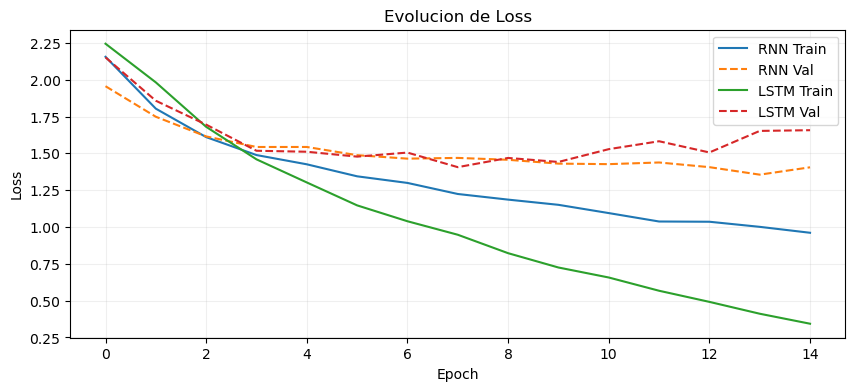

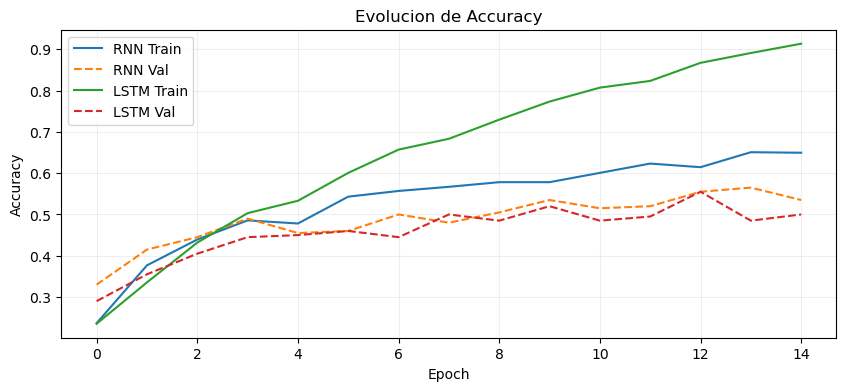

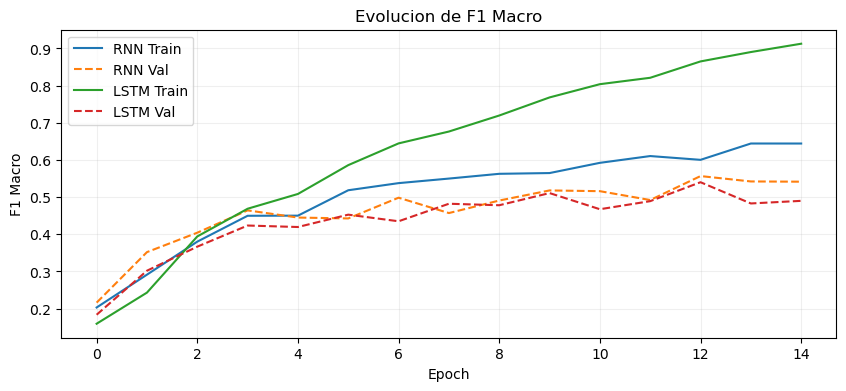


=== RNN ===
Validation Accuracy: 0.5350
Validation F1 Macro: 0.5415


,precision,recall,f1-score,support
blues,0.360000,0.450,0.400000,20.000
classical,0.882353,0.750,0.810811,20.000
country,0.400000,0.300,0.342857,20.000
disco,0.294118,0.500,0.370370,20.000
hiphop,0.476190,0.500,0.487805,20.000
jazz,0.550000,0.550,0.550000,20.000
metal,0.933333,0.700,0.800000,20.000
pop,0.789474,0.750,0.769231,20.000
reggae,0.545455,0.600,0.571429,20.000
rock,0.416667,0.250,0.312500,20.000


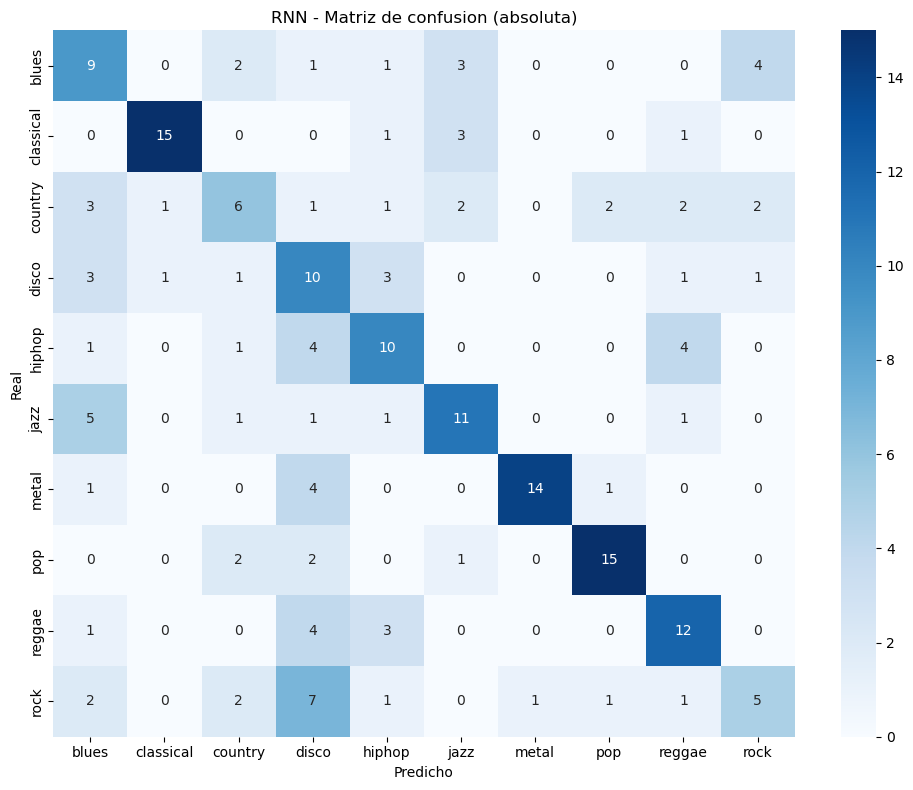

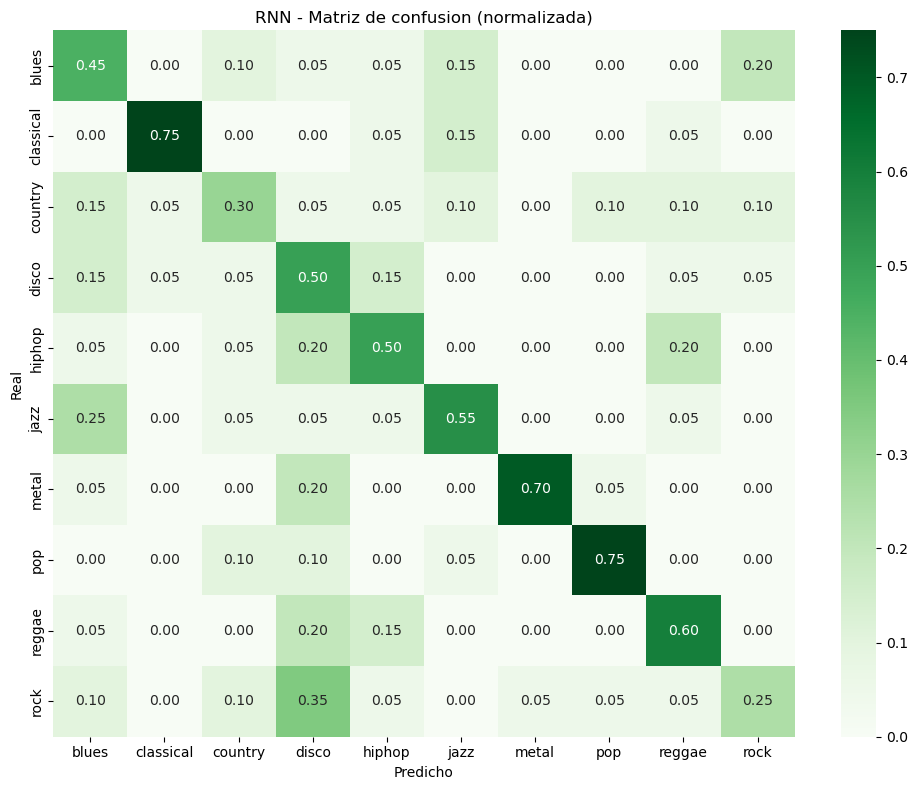


=== LSTM ===
Validation Accuracy: 0.5000
Validation F1 Macro: 0.4899


,precision,recall,f1-score,support
blues,0.428571,0.30,0.352941,20.0
classical,0.857143,0.90,0.878049,20.0
country,0.250000,0.20,0.222222,20.0
disco,0.400000,0.30,0.342857,20.0
hiphop,0.315789,0.30,0.307692,20.0
jazz,0.538462,0.70,0.608696,20.0
metal,0.750000,0.75,0.750000,20.0
pop,0.695652,0.80,0.744186,20.0
reggae,0.416667,0.50,0.454545,20.0
rock,0.227273,0.25,0.238095,20.0


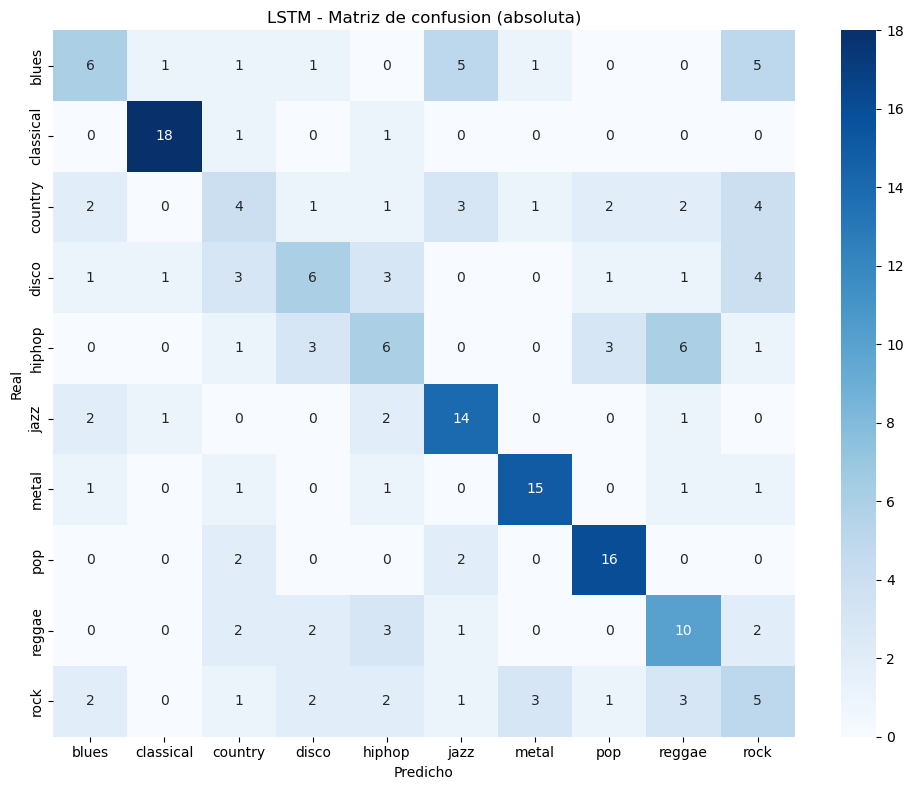

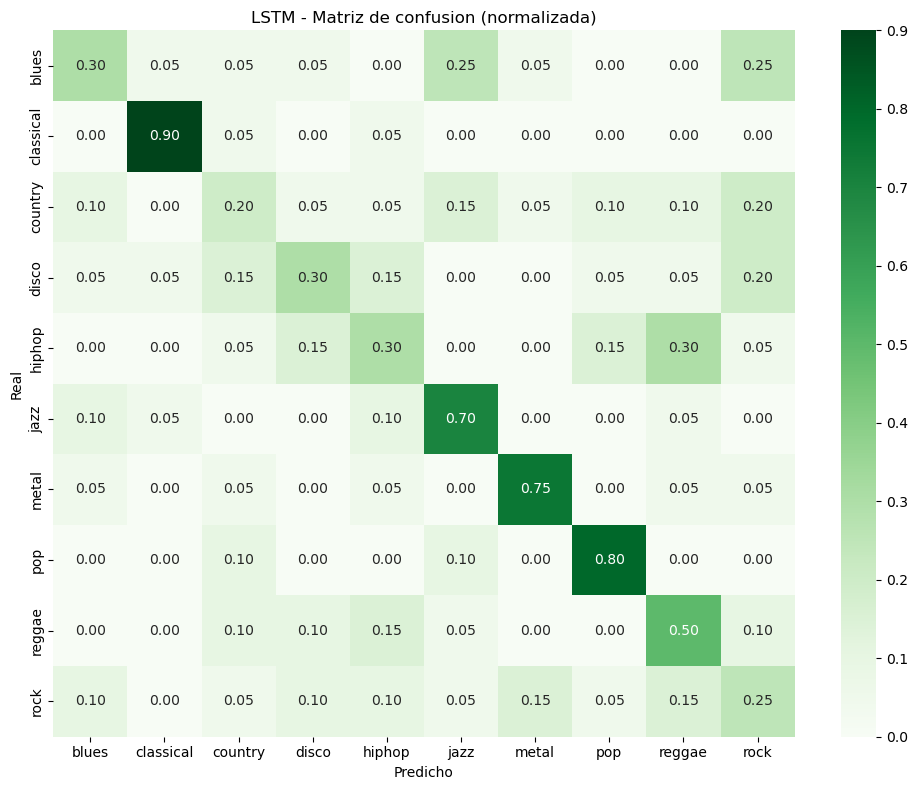


Tabla comparativa de modelos


,Modelo,Val Accuracy,Val F1 Macro
0,RNN,0.535,0.541500
1,LSTM,0.500,0.489928


Modelo ganador sugerido por F1 Macro: RNN


In [ ]:
models = {
  "RNN": rnn_model,
  "LSTM": lstm_model
}
histories = {
  "RNN": rnn_history,
  "LSTM": lstm_history
}

def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.numpy())

    return np.array(all_targets), np.array(all_preds)


def plot_metric(histories, metric, ylabel, title):
    plt.figure(figsize=(10, 4))
    for model_name, hist in histories.items():
        plt.plot(hist[f"train_{metric}"], label=f"{model_name} Train")
        plt.plot(hist[f"val_{metric}"], linestyle="--", label=f"{model_name} Val")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_metric(histories, metric="loss", ylabel="Loss", title="Evolucion de Loss")
plot_metric(histories, metric="acc", ylabel="Accuracy", title="Evolucion de Accuracy")
plot_metric(histories, metric="f1", ylabel="F1 Macro", title="Evolucion de F1 Macro")

eval_results = {}
for name, model in models.items():
    y_true, y_pred = get_predictions(model, val_loader, device)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=genres,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    eval_results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "report": report_dict,
        "cm": cm,
        "cm_norm": cm_norm
    }

    print(f"\n=== {name} ===")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1 Macro: {f1:.4f}")
    display(pd.DataFrame(report_dict).transpose())

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=genres,
        yticklabels=genres
    )
    plt.title(f"{name} - Matriz de confusion (absoluta)")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        xticklabels=genres,
        yticklabels=genres
    )
    plt.title(f"{name} - Matriz de confusion (normalizada)")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

comparison_rows = []
for name, res in eval_results.items():
    comparison_rows.append({
        "Modelo": name,
        "Val Accuracy": res["accuracy"],
        "Val F1 Macro": res["f1_macro"]
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by="Val F1 Macro",
    ascending=False
).reset_index(drop=True)

print("\nTabla comparativa de modelos")
display(comparison_df)

winner_model_name = comparison_df.loc[0, "Modelo"]
best_model = models[winner_model_name]
print(f"Modelo ganador sugerido por F1 Macro: {winner_model_name}")

## 4. Prueba con canciones nuevas (1.5 punto)

Seleccionar al menos **10 canciones que no formen parte del dataset GTZAN**, las cuales serán utilizadas para evaluar la capacidad de generalización del modelo ganador.

Las canciones pueden provenir de plataformas de música, bibliotecas de audio libres de derechos, colecciones personales o descargadas de youtube. No está permitido utilizar canciones pertenecientes al dataset de entrenamiento, validación o prueba utilizado durante el desarrollo del modelo.

* Debe haber al menos una canción representativa de cada uno de los géneros musicales presentes en GTZAN.

* Aplicar exactamente el mismo proceso de preprocesamiento utilizado durante el entrenamiento del modelo, incluyendo:

  * Conversión a la frecuencia de muestreo utilizada.
  * Extracción de MFCCs.
  * Ajuste de longitud temporal mediante padding o truncation.
  * Normalización de las características.

* Pasar cada canción por el **modelo ganador** entrenado y mostrar:

  * Nombre de la canción.
  * Score asignado a cada género musical (normalizado entre 0 y 1 o entre 0% y 100%).
  * Género musical esperado.
  * La clase ganadora inferida por el modelo.
  * Un reproductor dentro del notebook hecho con `from IPython.display import Audio, display` por cada canción.

* Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  * Similitudes entre géneros musicales.
  * Calidad del audio.
  * Mezcla de estilos musicales.
  * Limitaciones del dataset utilizado para el entrenamiento.

* Redactar conclusiones sobre la capacidad de generalización del modelo frente a canciones que nunca fueron vistas durante el entrenamiento.
